In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWF4L2F1bGEtcXVhbnR1bS9jb250ZW50LzA5LWludGVyZmVyZW5jaWEtZGV1dHNjaC1qb3pzYQ=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/importlib/_bootstrap_external.py": 1787687117.0310943, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/codecs.py": 1787687116.7980936, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/aliases.py": 1787687116.852094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/__init__.py": 1787687116.8510938, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/encodings/utf_8.py": 1787687116.888094, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/abc.py": 1787687116.7790935, "/home/max/.local/share/uv/python/cpython-3.10-linux-x86_64-gnu/lib/python3.10/io.py": 1787687117.0350945, "/home/max/.local/share/uv/python/cpython-3.10-linu

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere

In [3]:
# Criar circuito com 2 qubits
qc = QuantumCircuit(2, 1)  # 2 Qubits, 1 Bit clássico
qc.draw("mpl")

# 1. PREPARAÇÃO
# Colocar o Qubit 0 (Controle) em Superposição |+>
qc.h(0)

# Colocar o Qubit 1 (Alvo) no estado |- >
# Para isso: aplicamos X (vira 1) e depois H (vira menos)
qc.x(1)
qc.h(1)

# 2. O KICKBACK
# Aplicamos CNOT. O alvo (q1) está em |->.
# Isso deve fazer o q0 virar |-> "por tabela".
qc.cx(0, 1)

# 3. VERIFICAÇÃO
# Como saber se q0 virou |->?
# Se aplicarmos H novamente:
# H em |+> volta para 0
# H em |-> volta para 1
qc.h(0)

# Medimos APENAS o qubit de controle (q0)
qc.measure(0, 0)

# Executar
simulador = AerSimulator()
job = simulador.run(transpile(qc, simulador), shots=1000)
print("Resultado do Controle:", job.result().get_counts())

Resultado do Controle: {'1': 1000}


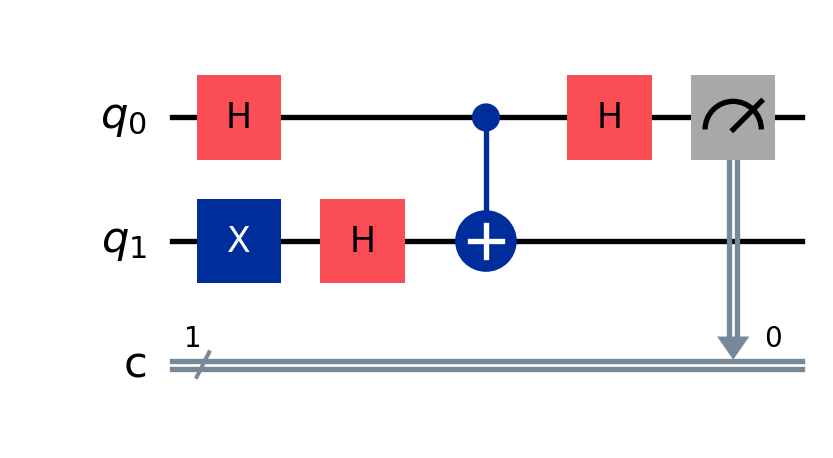

In [4]:
# Visualizar o circuito completo
qc.draw('mpl')

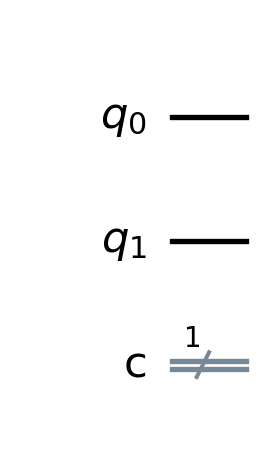

In [5]:
# Criar circuito com 2 qubits
qc = QuantumCircuit(2, 1) # 2 Qubits, 1 Bit clássico

# Desenhar o circuito
qc.draw('mpl')

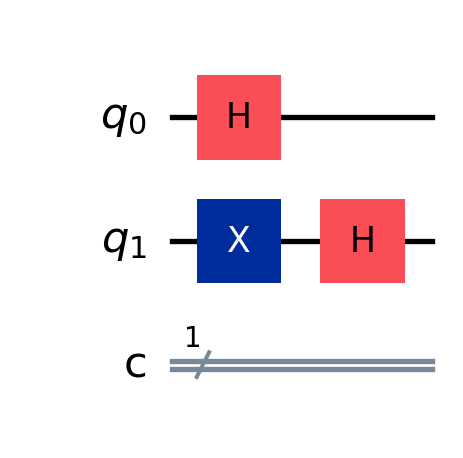

In [6]:
# 1. PREPARAÇÃO
# Colocar o Qubit 0 (Controle) em Superposição |+>
qc.h(0)

# Colocar o Qubit 1 (Alvo) no estado |- > 
# Para isso: aplicamos X (vira 1) e depois H (vira menos)
qc.x(1)
qc.h(1)

# Desenhar o circuito
qc.draw('mpl')

Estado inicial: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))


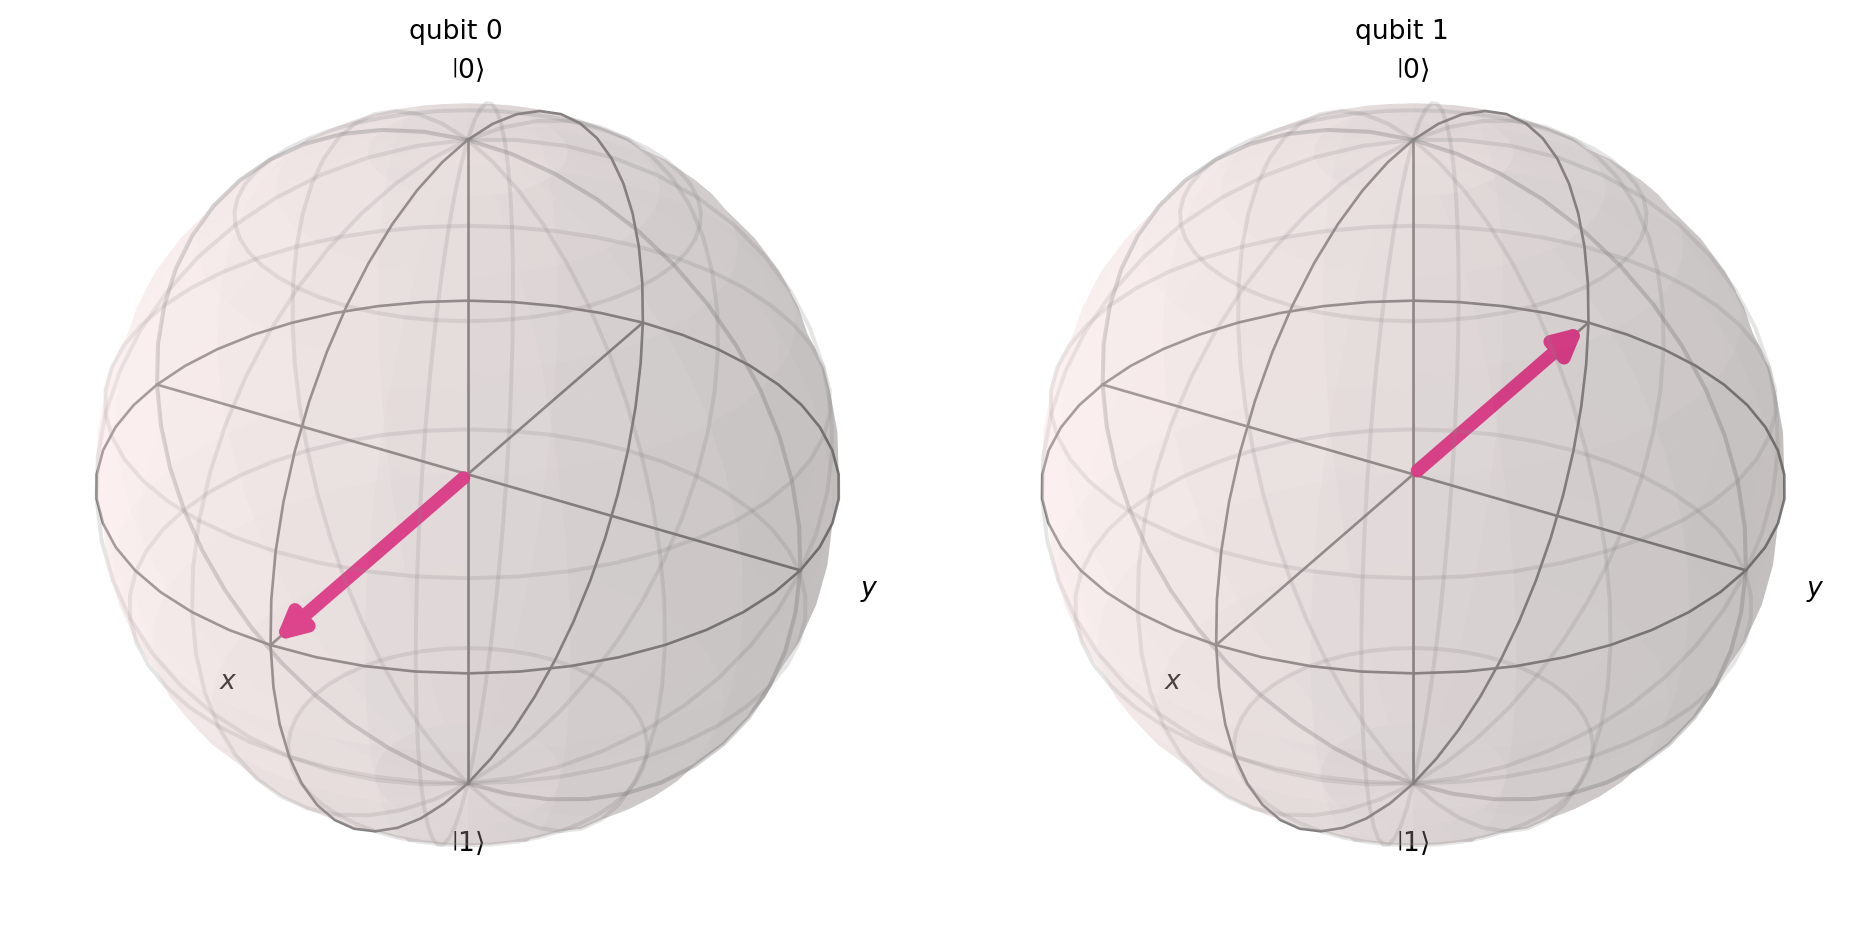

In [7]:
# Visualizar o estado após preparação
estado_inicial = Statevector(qc)
print(f"Estado inicial: {estado_inicial}")
display(plot_bloch_multivector(estado_inicial))


Q-Sphere mostrando ambos os qubits:


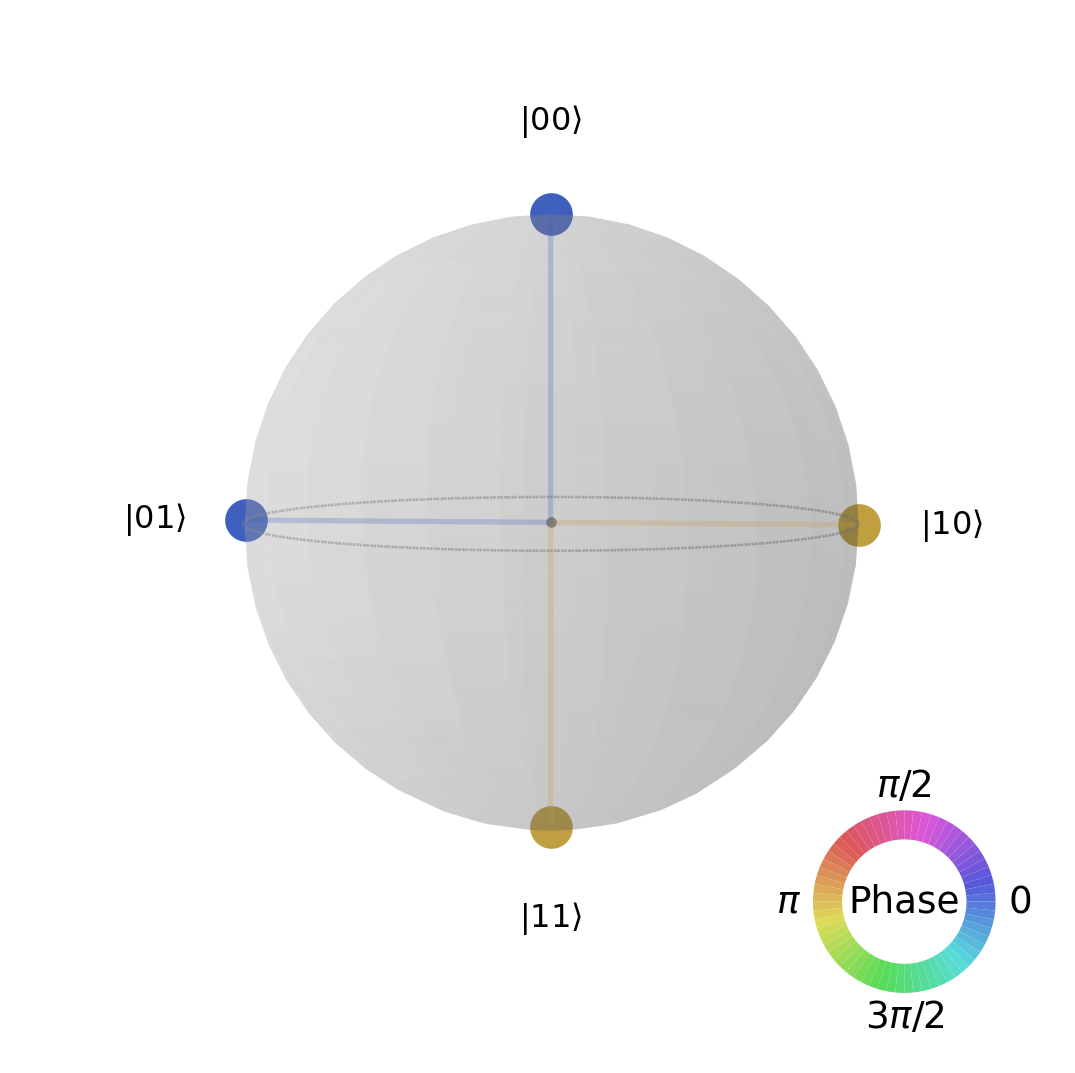

In [8]:
print("\nQ-Sphere mostrando ambos os qubits:")
display(plot_state_qsphere(estado_inicial))

In [9]:
# 🌐 Visualização INTERATIVA da Q-Sphere
# Importar a função do módulo quantum_viz (localizado em ../src)
import sys
from pathlib import Path
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "src").is_dir() and str(p / "src") not in sys.path:
        sys.path.insert(0, str(p / "src"))
from quantum_viz import plot_qsphere_interactive

# 🎨 Criar e exibir a visualização
print("\n🌐 Q-Sphere INTERATIVA:")
print("   → Magenta = Fase positiva (+)")
print("   → Ciano = Fase negativa (-)")
print("   → Tamanho = Probabilidade\n")

# A função plot_qsphere_interactive salva automaticamente e abre no navegador
fig = plot_qsphere_interactive(estado_inicial)


🌐 Q-Sphere INTERATIVA:
   → Magenta = Fase positiva (+)
   → Ciano = Fase negativa (-)
   → Tamanho = Probabilidade



✅ Visualização 3D salva em: /home/max/aula-quantum/content/09-interferencia-deutsch-jozsa/qsphere_interativa.html


In [10]:
# 2. O KICKBACK
# Aplicamos CNOT. O alvo (q1) está em |->.
# Isso deve fazer o q0 virar |-> "por tabela".
qc.cx(0, 1)

Estado após CNOT: Statevector([ 0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j],
            dims=(2, 2))

Esfera de Bloch - Note a mudança de fase no qubit 0:


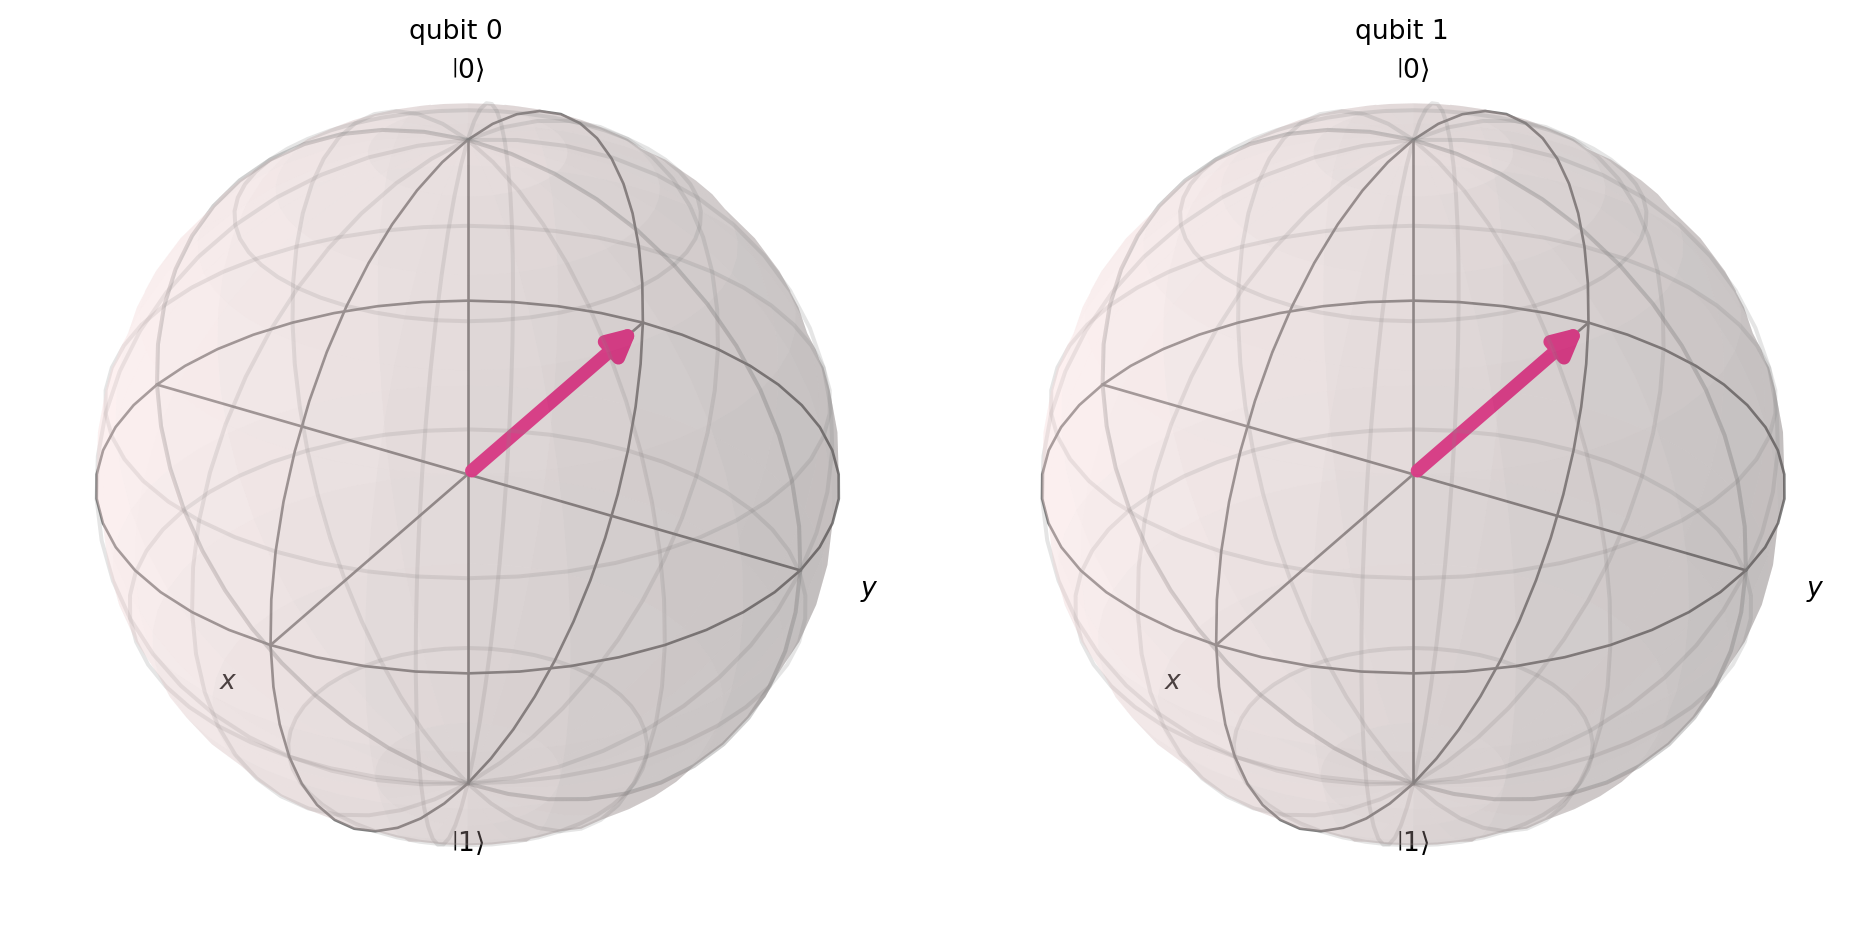


Q-Sphere:


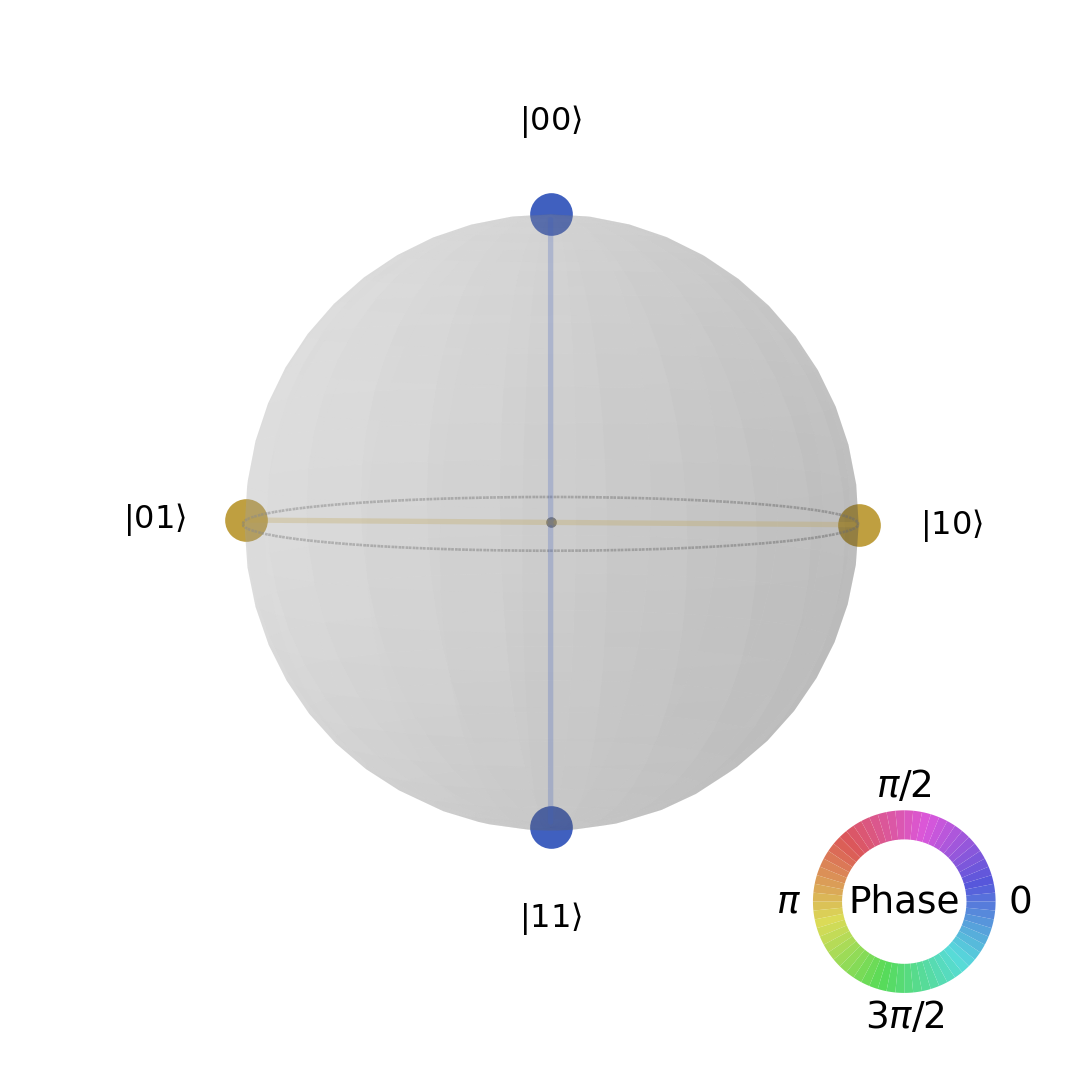

In [11]:
# Visualizar após o CNOT (Phase Kickback aconteceu)
estado_apos_kickback = Statevector(qc)
print(f"Estado após CNOT: {estado_apos_kickback}")
print("\nEsfera de Bloch - Note a mudança de fase no qubit 0:")
display(plot_bloch_multivector(estado_apos_kickback))
print("\nQ-Sphere:")
display(plot_state_qsphere(estado_apos_kickback))

In [12]:
# 3. VERIFICAÇÃO
# Como saber se q0 virou |->?
# Se aplicarmos H novamente:
# H em |+> volta para 0
# H em |-> volta para 1
qc.h(0)

Estado após verificação (H no q0): Statevector([ 2.29934717e-17+0.j,  7.07106781e-01+0.j, -2.29934717e-17+0.j,
             -7.07106781e-01+0.j],
            dims=(2, 2))


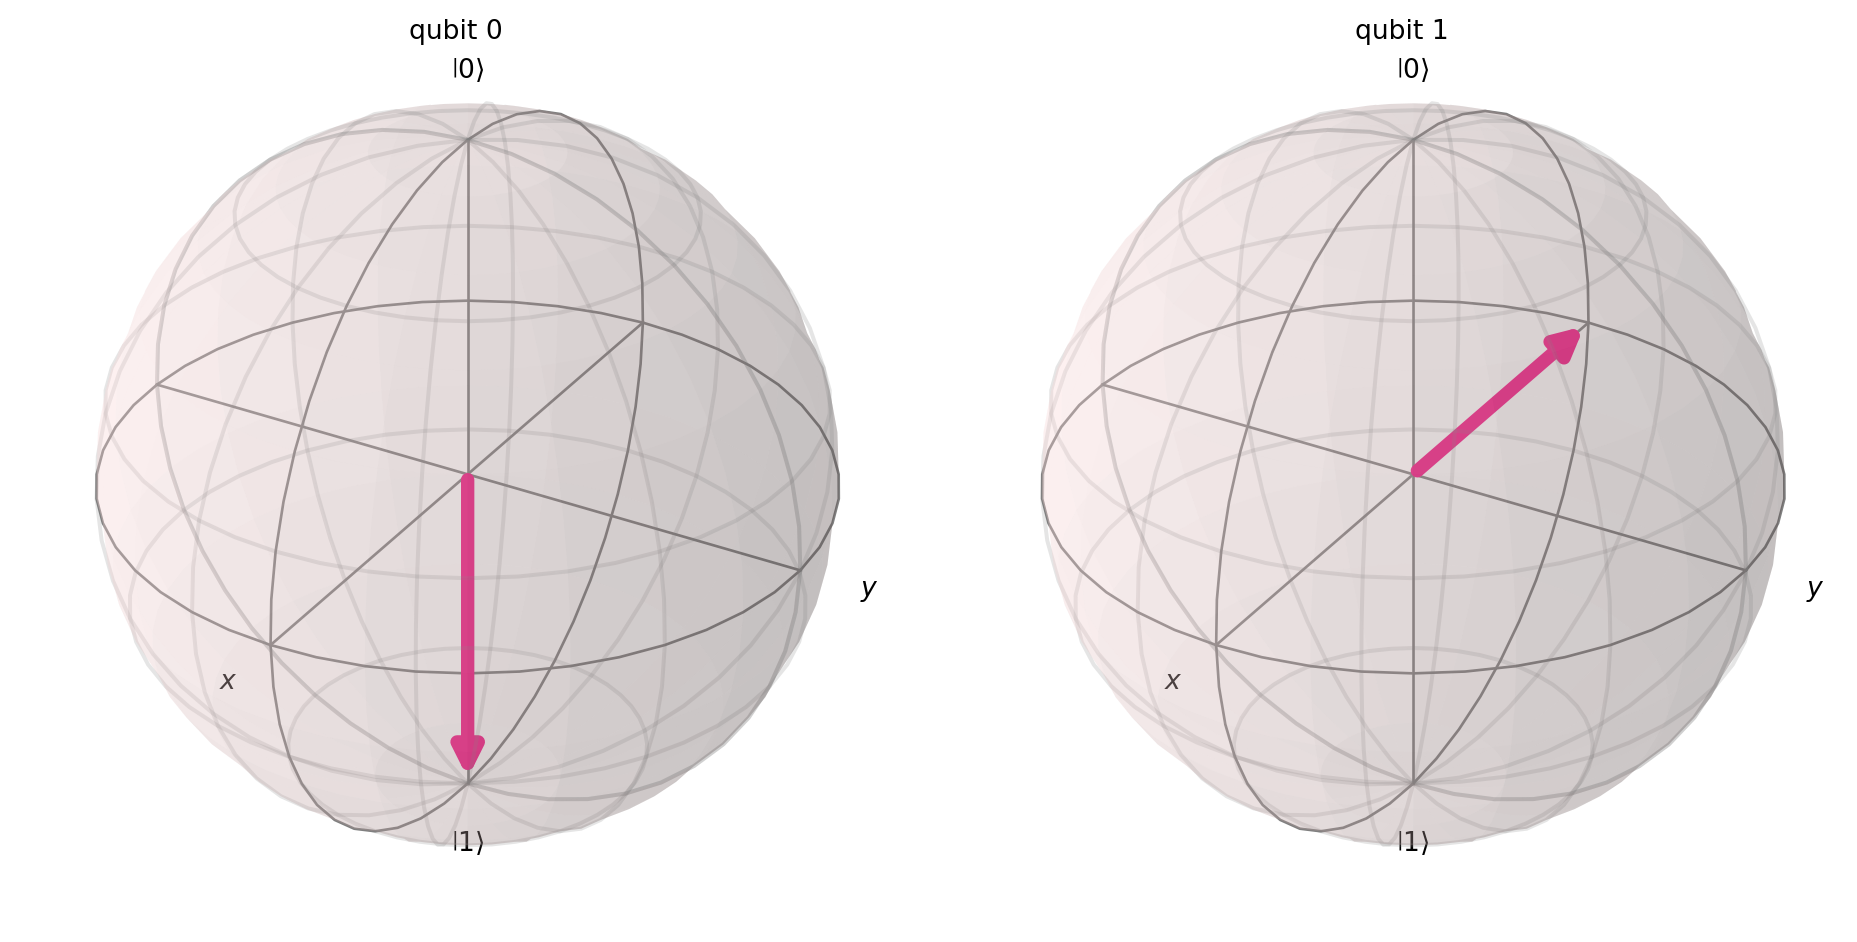


Q-Sphere:


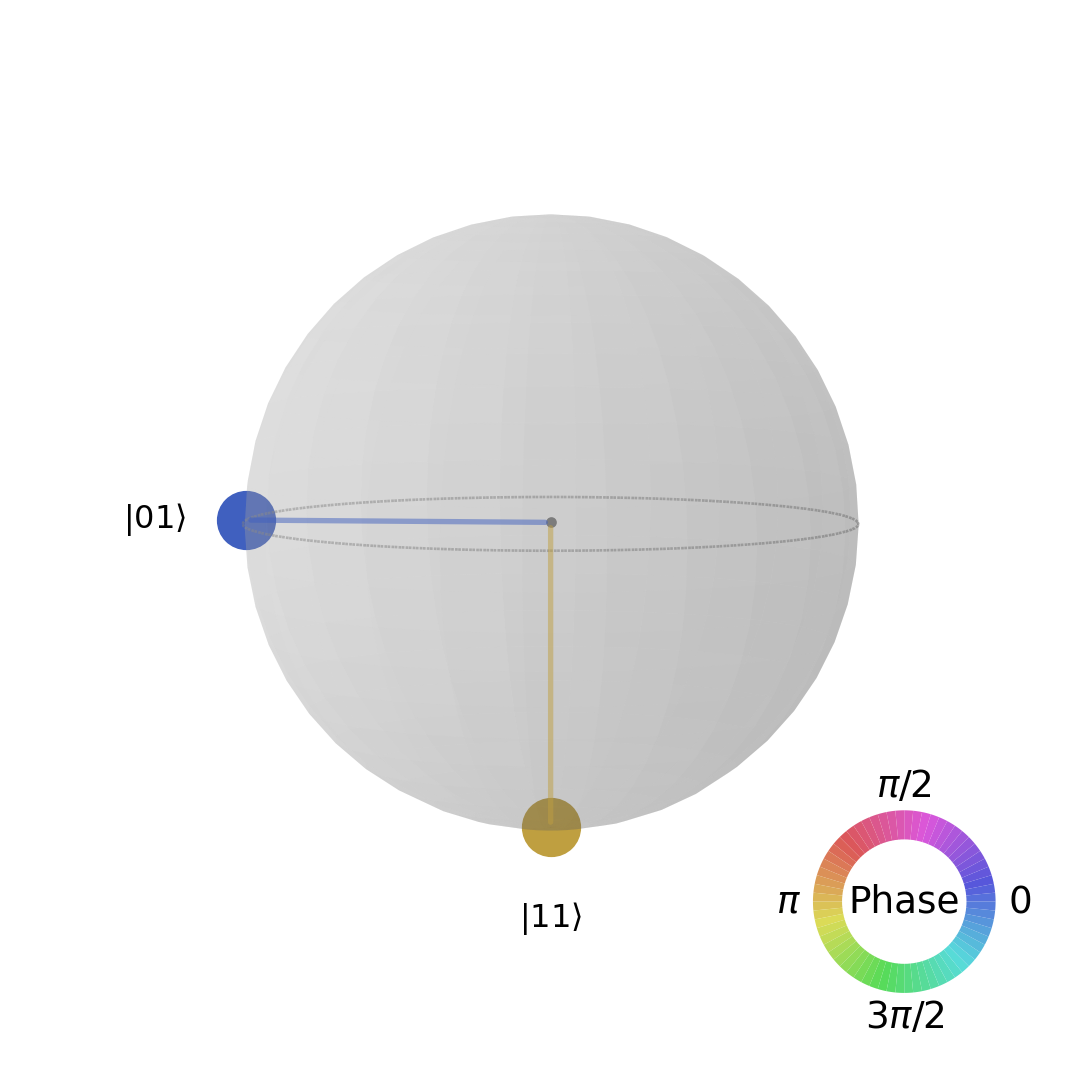

In [13]:
estado_verificacao = Statevector(qc)
print(f"Estado após verificação (H no q0): {estado_verificacao}")
display(plot_bloch_multivector(estado_verificacao))
print("\nQ-Sphere:")
display(plot_state_qsphere(estado_verificacao))

In [14]:
# Medimos APENAS o qubit de controle (q0)
qc.measure(0, 0)

# Executar
simulador = AerSimulator()
job = simulador.run(transpile(qc, simulador), shots=1000)
print("Resultado do Controle:", job.result().get_counts())

Resultado do Controle: {'1': 1000}


In [15]:
import random

def eh_constante_ou_balanceada(tabela_oculta):
    """
    Entra um vetor parecido com [0,1,0,1,1], este com 5 bits, por exemplo.
    Procura saber se o vetor é constante (só tem 0s ou 1s) ou balanceada (tem 0s e 1s misturados)
    """
    historico_saidas = []
    
    # Testar até o limite do pior caso
    for i in range(limite_pior_caso):
        print(f"Input: {i:03b} -> Output: {tabela_oculta[i]}")
        historico_saidas.append(tabela_oculta[i])
        
        # Se a lista tiver somente 0s ou somente 1s, continuar
        # Caso contrário, já sabemos que é balanceada
        if 0 in historico_saidas and 1 in historico_saidas:
            print("Achamos ambos os valores! A função é balanceada.")
            return "Balanceada"
    
    print("Todos os valores são iguais! A função é constante.")
    return "Constante"

# Utilizando inicialmente 3 bits de entrada (000) para execução rápida e
# simplificação. Experimente depois aumentar para 15 bits. Você verá 
# como é lentooo...
n_bits = 3

# Número total de entradas possíveis (2^n_bits)
total_inputs = 2 ** n_bits

# Vamos fazer o teste contante aqui
tabela_oculta = []                          # Lista que representa a função oculta
valor = random.choice([0, 1])               # Escolhe aleatoriamente 0 ou 1 para toda a lista
tabela_oculta = [valor] * total_inputs      # Preenche a lista com o valor escolhido

print("Tabela oculta (caixa preta):")
print(tabela_oculta)                        # Exibe a tabela oculta

limite_pior_caso = (2 ** (n_bits-1)) + 1    # Limite para o pior caso (metade + 1)

# Aqui começa o teste
# Deverá verificar se a função é constante ou balanceada
# Se todos os valores forem iguais, é constante
# Se encontrar ambos os valores (0 e 1) dentro da lista, é balanceada.
# Obviamente vai ser contante, pois preenchemos assim.

print("\nTestando se a função é constante ou balanceada:")
eh_constante_ou_balanceada(tabela_oculta)
    
# Agora vamos fazer o teste balanceado
tabela_oculta = []                          # Resetar a lista
metade = total_inputs // 2                  # Calcular a metade do total de entradas
tabela_oculta = [0] * metade + [1] * metade # Preencher metade com 0s e metade com 1s
random.shuffle(tabela_oculta)               # Embaralhar a lista para aleatoriedade

print("\nTabela oculta (caixa preta):")
print(tabela_oculta)                        # Exibe a tabela oculta

print("\nTestando se a função é constante ou balanceada:")
eh_constante_ou_balanceada(tabela_oculta)

Tabela oculta (caixa preta):
[1, 1, 1, 1, 1, 1, 1, 1]

Testando se a função é constante ou balanceada:
Input: 000 -> Output: 1
Input: 001 -> Output: 1
Input: 010 -> Output: 1
Input: 011 -> Output: 1
Input: 100 -> Output: 1
Todos os valores são iguais! A função é constante.

Tabela oculta (caixa preta):
[0, 1, 0, 1, 0, 0, 1, 1]

Testando se a função é constante ou balanceada:
Input: 000 -> Output: 0
Input: 001 -> Output: 1
Achamos ambos os valores! A função é balanceada.


'Balanceada'

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_histogram

In [17]:
# ============================================
# DEFINIÇÃO DOS ORÁCULOS
# ============================================

def oraculo_balanceado(n_qubits):
    """
    Cria um circuito que representa uma função BALANCEADA.
    
    Esta função retorna 0 para metade das entradas e 1 para a outra metade.
    Implementação: CNOTs de todos os qubits de entrada para o qubit de saída.
    
    Equivalente quântico de: tabela_oculta = [0]*metade + [1]*metade (embaralhado)
    """
    qc = QuantumCircuit(n_qubits + 1)
    for qubit in range(n_qubits):
        qc.cx(qubit, n_qubits) # CNOT de todos inputs para o alvo
    return qc

def oraculo_constante(n_qubits):
    """
    Cria um circuito que representa uma função CONSTANTE.
    
    Esta função retorna sempre 0 ou sempre 1 (independente da entrada).
    
    Implementação:
    - Retorna sempre 0: não faz nada (circuito identidade)
    - Retorna sempre 1: aplica X no qubit de saída
    
    Equivalente quântico de: tabela_oculta = [0] * total_inputs
                          ou: tabela_oculta = [1] * total_inputs
    """
    qc = QuantumCircuit(n_qubits + 1)
    # Não adicionamos portas, então a saída é constante 0
    # Para constante 1, descomente a linha abaixo:
    # qc.x(n_qubits)
    return qc

In [18]:
# 🎮 EXPERIMENTO INTERATIVO: Teste Ambos os Tipos de Função

import random

def executar_deutsch_jozsa(n_bits, tipo_funcao):
    """
    Executa o Algoritmo de Deutsch-Jozsa para um tipo específico de função.
    
    Args:
        n_bits: Número de bits de entrada
        tipo_funcao: "constante" ou "balanceada"
    """
    qc = QuantumCircuit(n_bits + 1, n_bits)
    
    # PASSO 1: Preparação
    for i in range(n_bits):
        qc.h(i)
    qc.x(n_bits)
    qc.h(n_bits)
    qc.barrier()
    
    # PASSO 2: Aplicar oráculo
    if tipo_funcao == "constante":
        valor_constante = random.choice([0, 1])
        oraculo = oraculo_constante(n_bits)
        if valor_constante == 1:
            oraculo.x(n_bits)
        tipo_real = "CONSTANTE"
        tabela_classica = [valor_constante] * (2**n_bits)
    else:
        oraculo = oraculo_balanceado(n_bits)
        tipo_real = "BALANCEADA"
        metade = 2**(n_bits-1)
        tabela_classica = [0]*metade + [1]*metade
        random.shuffle(tabela_classica)
    
    qc = qc.compose(oraculo)
    qc.barrier()
    
    # PASSO 3: Interferência
    for i in range(n_bits):
        qc.h(i)
    
    # PASSO 4: Medição
    qc.measure(range(n_bits), range(n_bits))
    
    # PASSO 5: Executar
    simulador = AerSimulator()
    job = simulador.run(transpile(qc, simulador), shots=1)
    resultado = job.result().get_counts()
    medicao = list(resultado.keys())[0]
    
    # Interpretar
    if medicao == '0' * n_bits:
        resultado_quantum = "CONSTANTE"
    else:
        resultado_quantum = "BALANCEADA"
    
    # Exibir resultados
    print("="*70)
    print(f"🧪 TESTE COM FUNÇÃO {tipo_real}")
    print("="*70)
    print(f"📋 Tabela clássica (primeiros 8 valores): {tabela_classica[:8]}...")
    print(f"⚛️  Medição quântica: {medicao}")
    print(f"🎯 Resultado do algoritmo: {resultado_quantum}")
    
    if resultado_quantum == tipo_real:
        print("✅ CORRETO! O algoritmo identificou o tipo corretamente!")
    else:
        print("❌ ERRO! Algo deu errado...")
    
    print(f"\n💡 Consultas necessárias:")
    print(f"   • Clássico: até {(2**(n_bits-1)) + 1} consultas")
    print(f"   • Quântico: 1 consulta")
    print("="*70)
    
    return qc

# ============================================
# TESTAR AMBOS OS CASOS
# ============================================

n = 3  # Experimente com 5, 10 ou até 15 bits!

print("\n🔬 EXPERIMENTO 1: Função Constante\n")
circ1 = executar_deutsch_jozsa(n, "constante")

print("\n🔬 EXPERIMENTO 2: Função Balanceada\n")
circ2 = executar_deutsch_jozsa(n, "balanceada")

print("\n📊 CONCLUSÃO:")
print(f"   Com {n} bits de entrada, o computador quântico resolve o problema")
print(f"   com apenas 1 consulta, enquanto o clássico precisaria de até")
print(f"   {(2**(n-1)) + 1} consultas no pior caso!")
print(f"   Isso é uma vantagem de {(2**(n-1)) + 1}x! 🚀")


🔬 EXPERIMENTO 1: Função Constante



🧪 TESTE COM FUNÇÃO CONSTANTE
📋 Tabela clássica (primeiros 8 valores): [0, 0, 0, 0, 0, 0, 0, 0]...
⚛️  Medição quântica: 000
🎯 Resultado do algoritmo: CONSTANTE
✅ CORRETO! O algoritmo identificou o tipo corretamente!

💡 Consultas necessárias:
   • Clássico: até 5 consultas
   • Quântico: 1 consulta

🔬 EXPERIMENTO 2: Função Balanceada



🧪 TESTE COM FUNÇÃO BALANCEADA
📋 Tabela clássica (primeiros 8 valores): [0, 1, 0, 1, 1, 0, 0, 1]...
⚛️  Medição quântica: 111
🎯 Resultado do algoritmo: BALANCEADA
✅ CORRETO! O algoritmo identificou o tipo corretamente!

💡 Consultas necessárias:
   • Clássico: até 5 consultas
   • Quântico: 1 consulta

📊 CONCLUSÃO:
   Com 3 bits de entrada, o computador quântico resolve o problema
   com apenas 1 consulta, enquanto o clássico precisaria de até
   5 consultas no pior caso!
   Isso é uma vantagem de 5x! 🚀


Circuito quântico do Algoritmo de Deutsch-Jozsa:


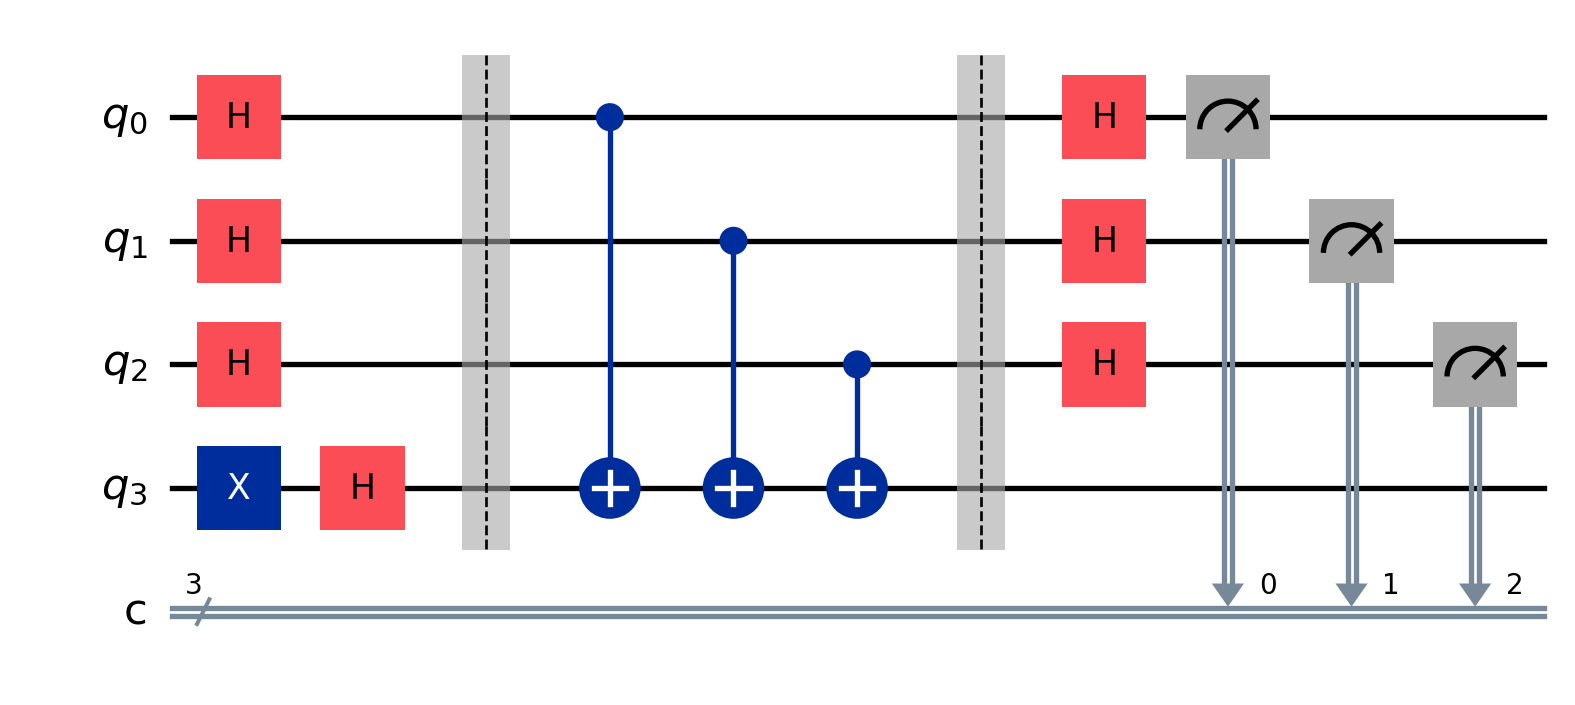

In [19]:
# Desenhar o circuito completo
print("Circuito quântico do Algoritmo de Deutsch-Jozsa:")
display(circ2.draw('mpl'))

In [20]:
# ============================================
# DEFINIÇÃO DOS ORÁCULOS
# ============================================

def oraculo_balanceado(n_qubits):
    """
    Cria um circuito que representa uma função BALANCEADA.
    
    Esta função retorna 0 para metade das entradas e 1 para a outra metade.
    Implementação: CNOTs de todos os qubits de entrada para o qubit de saída.
    
    Equivalente quântico de: tabela_oculta = [0]*metade + [1]*metade (embaralhado)
    """
    qc = QuantumCircuit(n_qubits + 1)
    for qubit in range(n_qubits):
        qc.cx(qubit, n_qubits) # CNOT de todos inputs para o alvo
    return qc

def oraculo_constante(n_qubits):
    """
    Cria um circuito que representa uma função CONSTANTE.
    
    Esta função retorna sempre 0 ou sempre 1 (independente da entrada).
    
    Implementação:
    - Retorna sempre 0: não faz nada (circuito identidade)
    - Retorna sempre 1: aplica X no qubit de saída
    
    Equivalente quântico de: tabela_oculta = [0] * total_inputs
                          ou: tabela_oculta = [1] * total_inputs
    """
    qc = QuantumCircuit(n_qubits + 1)
    # Não adicionamos portas, então a saída é constante 0
    # Para constante 1, descomente a linha abaixo:
    # qc.x(n_qubits)
    return qc

In [21]:
# ============================================
# CONSTRUÇÃO DO ALGORITMO PASSO A PASSO
# ============================================

n = 3  # Número de bits de entrada
qc = QuantumCircuit(n + 1, n)

print("="*70)
print("🎯 ALGORITMO DE DEUTSCH-JOZSA - CONSTRUÇÃO PASSO A PASSO")
print("="*70)
print(f"Testando com {n} qubits de entrada")
print("="*70)

# ─────────────────────────────────────────────
# PASSO 1: Inicialização
# ─────────────────────────────────────────────
print("\n📍 PASSO 1: Inicialização")
print("   Colocando qubits de entrada em superposição |+⟩")
print("   Preparando qubit auxiliar no estado |−⟩ para phase kickback")

# Inputs (0 a n-1) em Superposição |+>
qc.h(range(n))

# Alvo (último qubit) no estado |-> para gerar o KICKBACK
qc.x(n)
qc.h(n)

qc.barrier()

print("   ✅ Preparação concluída!")

🎯 ALGORITMO DE DEUTSCH-JOZSA - CONSTRUÇÃO PASSO A PASSO
Testando com 3 qubits de entrada

📍 PASSO 1: Inicialização
   Colocando qubits de entrada em superposição |+⟩
   Preparando qubit auxiliar no estado |−⟩ para phase kickback
   ✅ Preparação concluída!


Estado inicial - Superposição uniforme de todos os 8 estados:


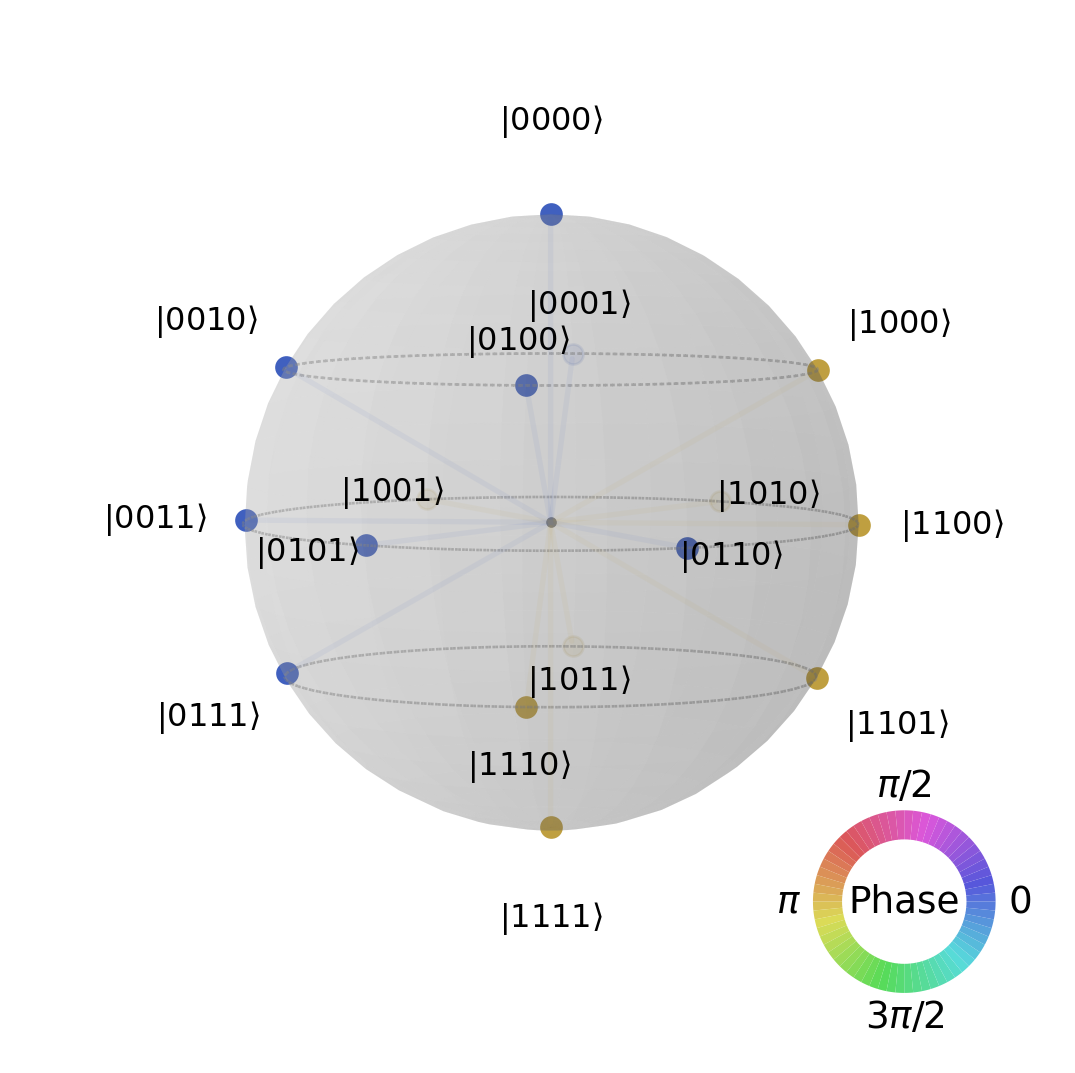

In [22]:
# Visualizar estado inicial
estado_inicial_dj = Statevector(qc)
print("Estado inicial - Superposição uniforme de todos os 8 estados:")
display(plot_state_qsphere(estado_inicial_dj))

In [23]:
# ─────────────────────────────────────────────
# PASSO 2: Aplicação do Oráculo
# ─────────────────────────────────────────────
print("\n📍 PASSO 2: Aplicação do Oráculo")
print("   Vamos usar um oráculo BALANCEADO")
print("   Aqui acontece a 'mágica': testamos TODAS as entradas simultaneamente!")

# Vamos usar o balanceado. O algoritmo deve descobrir isso.
oraculo = oraculo_balanceado(n)
# Adicionamos o oráculo ao nosso circuito principal
qc = qc.compose(oraculo)

qc.barrier()

print("   ✅ Oráculo aplicado! Informação codificada nas fases.")


📍 PASSO 2: Aplicação do Oráculo
   Vamos usar um oráculo BALANCEADO
   Aqui acontece a 'mágica': testamos TODAS as entradas simultaneamente!
   ✅ Oráculo aplicado! Informação codificada nas fases.


Estado após oráculo - Note as mudanças de fase:


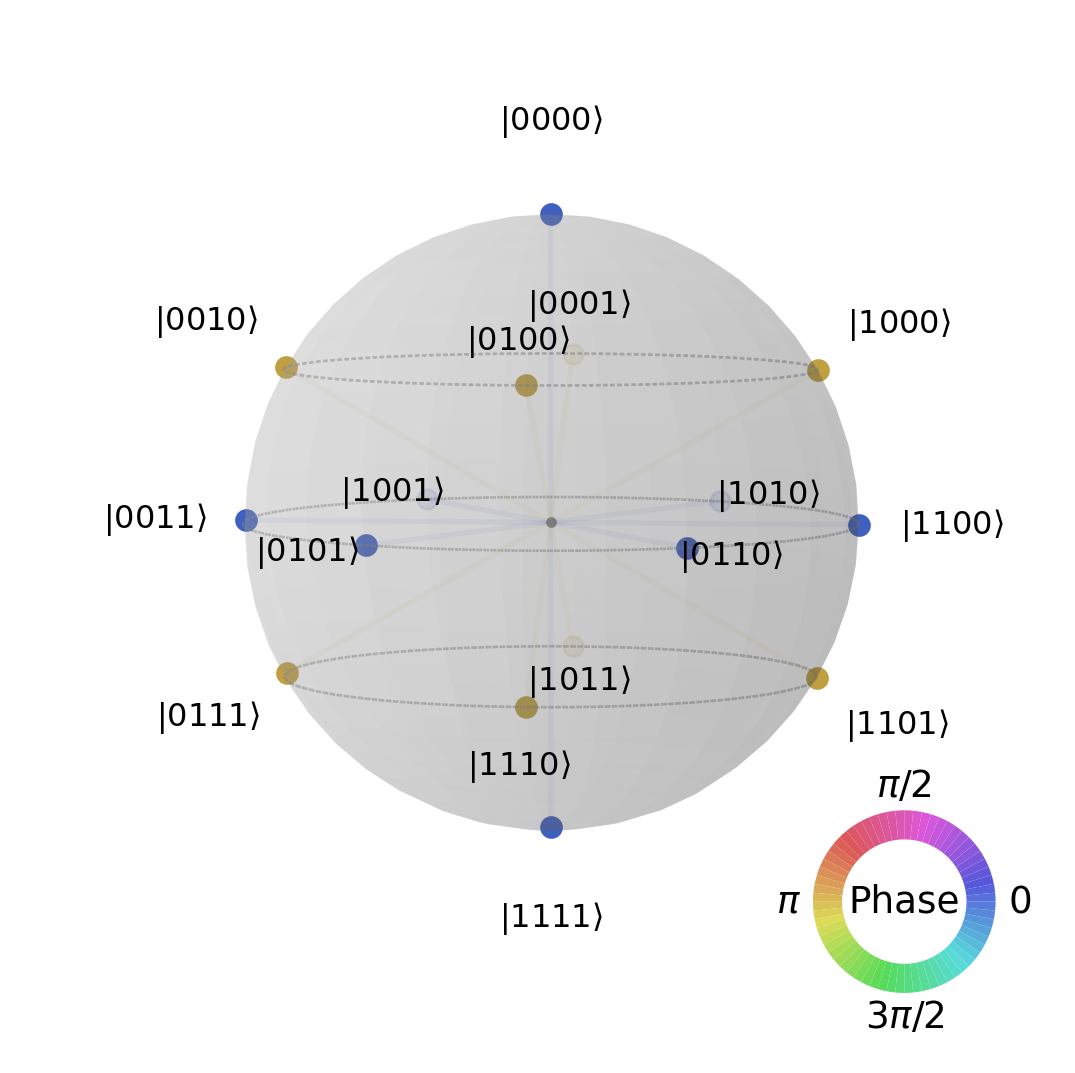

In [24]:
# Visualizar estado após oráculo
estado_apos_oraculo_dj = Statevector(qc)
print("Estado após oráculo - Note as mudanças de fase:")
display(plot_state_qsphere(estado_apos_oraculo_dj))

In [25]:
# ─────────────────────────────────────────────
# PASSO 3: Interferência Final
# ─────────────────────────────────────────────
print("\n📍 PASSO 3: Interferência")
print("   Aplicando Hadamard novamente para converter FASE em AMPLITUDE")

# Aplicamos H em todos os inputs novamente.
# Isso transforma o padrão de fase (criado pelo kickback) em resposta binária.
qc.h(range(n))

print("   ✅ Interferência concluída! Pronto para medir.")


📍 PASSO 3: Interferência
   Aplicando Hadamard novamente para converter FASE em AMPLITUDE
   ✅ Interferência concluída! Pronto para medir.


Estado antes da medição - Após interferência:


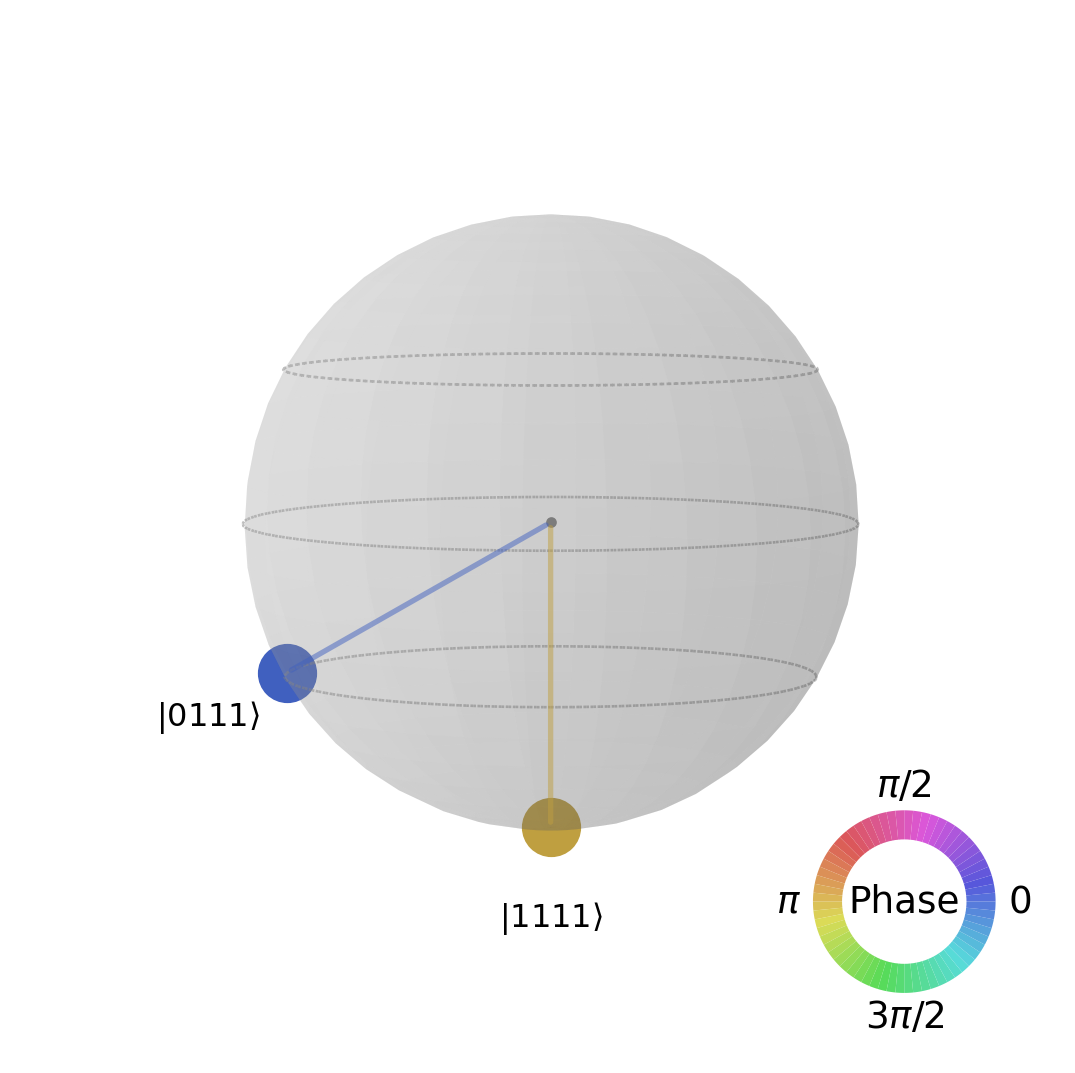

In [26]:
# Visualizar estado antes da medição
estado_antes_medicao = Statevector(qc)
print("Estado antes da medição - Após interferência:")
display(plot_state_qsphere(estado_antes_medicao))

In [27]:
# ─────────────────────────────────────────────
# PASSO 4: Medição
# ─────────────────────────────────────────────
print("\n📍 PASSO 4: Medição")
print("   Medindo apenas os qubits de entrada (não precisamos medir o auxiliar)")

# Medimos APENAS os qubits de entrada (0 a n-1)
qc.measure(range(n), range(n))

print("   ✅ Circuito completo! Pronto para executar.")
print("="*70)


📍 PASSO 4: Medição
   Medindo apenas os qubits de entrada (não precisamos medir o auxiliar)
   ✅ Circuito completo! Pronto para executar.



🚀 EXECUTANDO O ALGORITMO...



📊 Resultado da medição (1000 execuções): {'111': 1000}

📋 INTERPRETAÇÃO DO RESULTADO
   ✅ Nunca medimos '000' → A função é BALANCEADA
   (Interferência destrutiva em |000⟩)

💡 VANTAGEM QUÂNTICA:
   • Versão Clássica: até 5 consultas necessárias
   • Versão Quântica: 1 consulta (sempre!)
   • Speedup: 5x mais rápido!


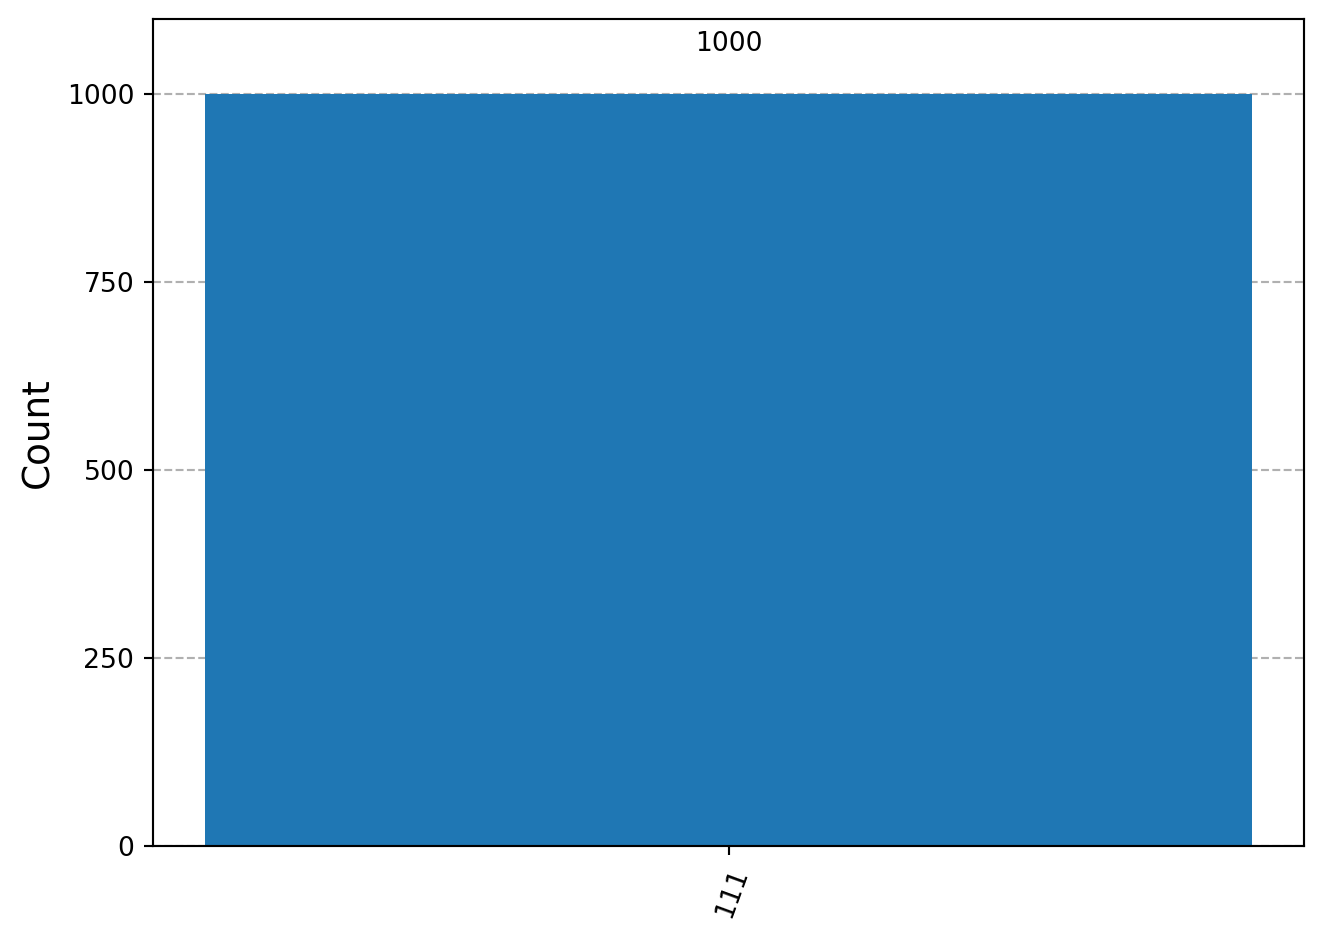

In [28]:
# ─────────────────────────────────────────────
# PASSO 5: Execução e Interpretação
# ─────────────────────────────────────────────
print("\n🚀 EXECUTANDO O ALGORITMO...\n")

# Executar no simulador
simulador = AerSimulator()
job = simulador.run(transpile(qc, simulador), shots=1000)
resultado = job.result().get_counts()

print(f"📊 Resultado da medição (1000 execuções): {resultado}")
print("\n" + "="*70)
print("📋 INTERPRETAÇÃO DO RESULTADO")
print("="*70)

if '000' in resultado:
    print("   ❌ Medimos '000' → A função é CONSTANTE")
    print("   (Interferência construtiva em |000⟩)")
else:
    print("   ✅ Nunca medimos '000' → A função é BALANCEADA")
    print("   (Interferência destrutiva em |000⟩)")

print("\n💡 VANTAGEM QUÂNTICA:")
print(f"   • Versão Clássica: até {(2**(n-1)) + 1} consultas necessárias")
print(f"   • Versão Quântica: 1 consulta (sempre!)")
print(f"   • Speedup: {(2**(n-1)) + 1}x mais rápido!")
print("="*70)
    
# Visualizar histograma
plot_histogram(resultado)